In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../outputs/rfm_clustered_table.csv')

# Log-transform Monetary for regression target
df['Log_Monetary'] = np.log1p(df['Monetary'])

# Split by cluster
cluster0 = df[df['Cluster'] == 0].copy()
cluster1 = df[df['Cluster'] == 1].copy()

print(f"Cluster 0 (Single-Purchase): {len(cluster0)} guests")
print(f"Cluster 1 (Loyal): {len(cluster1)} guests")

Cluster 0 (Single-Purchase): 90551 guests
Cluster 1 (Loyal): 2806 guests


In [3]:
# Cluster 0: drop Frequency (no variance) and Tenure (limited value per feedback)
cluster0_features = ['Recency', 'Avg_Review', 'Avg_Freight', 'Payment_Type_Encoded']
X0 = cluster0[cluster0_features]
y0 = cluster0['Log_Monetary']

# Cluster 1: keep all 6 features
cluster1_features = ['Recency', 'Frequency', 'Avg_Review', 'Avg_Freight', 'Payment_Type_Encoded', 'Tenure']
X1 = cluster1[cluster1_features]
y1 = cluster1['Log_Monetary']

print("Cluster 0 features:", cluster0_features, "| shape:", X0.shape)
print("Cluster 1 features:", cluster1_features, "| shape:", X1.shape)

Cluster 0 features: ['Recency', 'Avg_Review', 'Avg_Freight', 'Payment_Type_Encoded'] | shape: (90551, 4)
Cluster 1 features: ['Recency', 'Frequency', 'Avg_Review', 'Avg_Freight', 'Payment_Type_Encoded', 'Tenure'] | shape: (2806, 6)


In [4]:
from sklearn.model_selection import train_test_split

splits = {}

for split_name, test_size in [('70_30', 0.30), ('80_20', 0.20), ('95_5', 0.05)]:
    X0_train, X0_test, y0_train, y0_test = train_test_split(X0, y0, test_size=test_size, random_state=42)
    X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=test_size, random_state=42)
    
    splits[split_name] = {
        'cluster0': (X0_train, X0_test, y0_train, y0_test),
        'cluster1': (X1_train, X1_test, y1_train, y1_test)
    }
    
    print(f"{split_name} | Cluster 0 train/test: {len(X0_train)}/{len(X0_test)} | Cluster 1 train/test: {len(X1_train)}/{len(X1_test)}")

70_30 | Cluster 0 train/test: 63385/27166 | Cluster 1 train/test: 1964/842
80_20 | Cluster 0 train/test: 72440/18111 | Cluster 1 train/test: 2244/562
95_5 | Cluster 0 train/test: 86023/4528 | Cluster 1 train/test: 2665/141


In [5]:
from sklearn.tree import DecisionTreeRegressor

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Cluster 0
X0_train, X0_test, y0_train, y0_test = splits['80_20']['cluster0']
dt_grid0 = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_param_grid, scoring='r2', cv=5, n_jobs=-1)
dt_grid0.fit(X0_train, y0_train)
print("Cluster 0 - Decision Tree best params:", dt_grid0.best_params_)
print("Cluster 0 - Decision Tree best CV R²:", round(dt_grid0.best_score_, 4))

# Cluster 1
X1_train, X1_test, y1_train, y1_test = splits['80_20']['cluster1']
dt_grid1 = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_param_grid, scoring='r2', cv=5, n_jobs=-1)
dt_grid1.fit(X1_train, y1_train)
print("Cluster 1 - Decision Tree best params:", dt_grid1.best_params_)
print("Cluster 1 - Decision Tree best CV R²:", round(dt_grid1.best_score_, 4))

Cluster 0 - Decision Tree best params: {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Cluster 0 - Decision Tree best CV R²: 0.6193
Cluster 1 - Decision Tree best params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 20}
Cluster 1 - Decision Tree best CV R²: 0.4094


In [6]:
rf_param_grid_small = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'max_features': ['sqrt', 0.5]
}

rf_grid0 = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid_small, scoring='r2', cv=3, n_jobs=-1)
rf_grid0.fit(X0_train, y0_train)
print("Cluster 0 - Random Forest best params:", rf_grid0.best_params_)
print("Cluster 0 - Random Forest best CV R²:", round(rf_grid0.best_score_, 4))

rf_grid1 = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid_small, scoring='r2', cv=3, n_jobs=-1)
rf_grid1.fit(X1_train, y1_train)
print("Cluster 1 - Random Forest best params:", rf_grid1.best_params_)
print("Cluster 1 - Random Forest best CV R²:", round(rf_grid1.best_score_, 4))

Cluster 0 - Random Forest best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Cluster 0 - Random Forest best CV R²: 0.5921
Cluster 1 - Random Forest best params: {'max_depth': 10, 'max_features': 0.5, 'n_estimators': 200}
Cluster 1 - Random Forest best CV R²: 0.4316


In [7]:
from xgboost import XGBRegressor

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.85, 1.0]
}

# Cluster 0
xgb_grid0 = GridSearchCV(XGBRegressor(random_state=42, verbosity=0), xgb_param_grid, scoring='r2', cv=3, n_jobs=-1)
xgb_grid0.fit(X0_train, y0_train)
print("Cluster 0 - XGBoost best params:", xgb_grid0.best_params_)
print("Cluster 0 - XGBoost best CV R²:", round(xgb_grid0.best_score_, 4))

# Cluster 1
xgb_grid1 = GridSearchCV(XGBRegressor(random_state=42, verbosity=0), xgb_param_grid, scoring='r2', cv=3, n_jobs=-1)
xgb_grid1.fit(X1_train, y1_train)
print("Cluster 1 - XGBoost best params:", xgb_grid1.best_params_)
print("Cluster 1 - XGBoost best CV R²:", round(xgb_grid1.best_score_, 4))

Cluster 0 - XGBoost best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.85}
Cluster 0 - XGBoost best CV R²: 0.5953
Cluster 1 - XGBoost best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.85}
Cluster 1 - XGBoost best CV R²: 0.4439


In [8]:
results = []

models_cluster0 = {
    'Decision Tree': dt_grid0.best_estimator_,
    'Random Forest': rf_grid0.best_estimator_,
    'XGBoost': xgb_grid0.best_estimator_
}

models_cluster1 = {
    'Decision Tree': dt_grid1.best_estimator_,
    'Random Forest': rf_grid1.best_estimator_,
    'XGBoost': xgb_grid1.best_estimator_
}

for split_name in ['70_30', '80_20', '95_5']:
    X0_tr, X0_te, y0_tr, y0_te = splits[split_name]['cluster0']
    X1_tr, X1_te, y1_tr, y1_te = splits[split_name]['cluster1']
    
    for model_name, model in models_cluster0.items():
        model.fit(X0_tr, y0_tr)
        preds = model.predict(X0_te)
        results.append({
            'Cluster': 'Cluster 0', 'Model': model_name, 'Split': split_name,
            'RMSE': round(np.sqrt(mean_squared_error(y0_te, preds)), 4),
            'MAE': round(mean_absolute_error(y0_te, preds), 4),
            'R2': round(r2_score(y0_te, preds), 4)
        })
    
    for model_name, model in models_cluster1.items():
        model.fit(X1_tr, y1_tr)
        preds = model.predict(X1_te)
        results.append({
            'Cluster': 'Cluster 1', 'Model': model_name, 'Split': split_name,
            'RMSE': round(np.sqrt(mean_squared_error(y1_te, preds)), 4),
            'MAE': round(mean_absolute_error(y1_te, preds), 4),
            'R2': round(r2_score(y1_te, preds), 4)
        })

results_df = pd.DataFrame(results)
results_df

,Cluster,Model,Split,RMSE,MAE,R2
0,Cluster 0,Decision Tree,70_30,0.4875,0.3352,0.6258
1,Cluster 0,Random Forest,70_30,0.5037,0.3546,0.6005
2,Cluster 0,XGBoost,70_30,0.5026,0.3628,0.6023
3,Cluster 1,Decision Tree,70_30,0.5341,0.4199,0.3856
4,Cluster 1,Random Forest,70_30,0.5168,0.4086,0.4246
5,Cluster 1,XGBoost,70_30,0.5207,0.4114,0.4160
6,Cluster 0,Decision Tree,80_20,0.4926,0.3371,0.6220
7,Cluster 0,Random Forest,80_20,0.5058,0.3554,0.6014
8,Cluster 0,XGBoost,80_20,0.5048,0.3632,0.6031
9,Cluster 1,Decision Tree,80_20,0.5481,0.4344,0.3867


In [9]:
def freight_sensitivity_simulation(model, X_test, freight_col='Avg_Freight', perturbations=[-0.20, -0.10, 0, 0.10, 0.20]):
    results = []
    baseline_pred = model.predict(X_test)
    
    for pct in perturbations:
        X_perturbed = X_test.copy()
        X_perturbed[freight_col] = X_perturbed[freight_col] * (1 + pct)
        perturbed_pred = model.predict(X_perturbed)
        
        avg_pct_change = np.mean((perturbed_pred - baseline_pred) / baseline_pred) * 100
        
        results.append({
            'Freight_Perturbation_%': pct * 100,
            'Avg_Predicted_LogMonetary_Change_%': round(avg_pct_change, 3),
            'Mean_Predicted_LogMonetary': round(np.mean(perturbed_pred), 4)
        })
    
    return pd.DataFrame(results)

# Refit RF on 80/20 split (already done above, but ensuring it's the right state)
X0_train, X0_test, y0_train, y0_test = splits['80_20']['cluster0']
X1_train, X1_test, y1_train, y1_test = splits['80_20']['cluster1']

rf_grid0.best_estimator_.fit(X0_train, y0_train)
rf_grid1.best_estimator_.fit(X1_train, y1_train)

sensitivity_cluster0 = freight_sensitivity_simulation(rf_grid0.best_estimator_, X0_test)
sensitivity_cluster1 = freight_sensitivity_simulation(rf_grid1.best_estimator_, X1_test)

print("Cluster 0 Sensitivity:")
print(sensitivity_cluster0)
print("\nCluster 1 Sensitivity:")
print(sensitivity_cluster1)

Cluster 0 Sensitivity:
   Freight_Perturbation_%  Avg_Predicted_LogMonetary_Change_%  \
0                   -20.0                               4.375   
1                   -10.0                               5.254   
2                     0.0                               0.000   
3                    10.0                               9.803   
4                    20.0                               9.508   

   Mean_Predicted_LogMonetary  
0                      4.8348  
1                      4.8814  
2                      4.6888  
3                      5.0804  
4                      5.0780  

Cluster 1 Sensitivity:
   Freight_Perturbation_%  Avg_Predicted_LogMonetary_Change_%  \
0                   -20.0                              -3.011   
1                   -10.0                              -1.514   
2                     0.0                               0.000   
3                    10.0                               1.698   
4                    20.0                    

In [10]:
sensitivity_cluster0.to_csv('../outputs/sensitivity_cluster0.csv', index=False)
sensitivity_cluster1.to_csv('../outputs/sensitivity_cluster1.csv', index=False)
print("Saved.")

Saved.


In [11]:
def bootstrap_r2(model, X_test, y_test, n_iterations=1000):
    scores = []
    X_test_arr = X_test.reset_index(drop=True)
    y_test_arr = y_test.reset_index(drop=True)
    
    for _ in range(n_iterations):
        idx = resample(range(len(X_test_arr)))
        X_resample = X_test_arr.iloc[idx]
        y_resample = y_test_arr.iloc[idx]
        preds = model.predict(X_resample)
        scores.append(r2_score(y_resample, preds))
    
    ci_lower, ci_upper = np.percentile(scores, [2.5, 97.5])
    return ci_lower, ci_upper, np.mean(scores), np.std(scores)

# Cluster 1, using the 95/5 split test set (the small-sample concern)
X1_train_955, X1_test_955, y1_train_955, y1_test_955 = splits['95_5']['cluster1']

rf_grid1.best_estimator_.fit(X1_train_955, y1_train_955)
ci_lower, ci_upper, mean_r2, std_r2 = bootstrap_r2(rf_grid1.best_estimator_, X1_test_955, y1_test_955)

print(f"Cluster 1 (95/5 split, n={len(X1_test_955)}) Bootstrap R² Results:")
print(f"Mean R²: {round(mean_r2, 4)}")
print(f"Std Dev: {round(std_r2, 4)}")
print(f"95% CI: [{round(ci_lower, 4)}, {round(ci_upper, 4)}]")

Cluster 1 (95/5 split, n=141) Bootstrap R² Results:
Mean R²: 0.4575
Std Dev: 0.0646
95% CI: [0.3245, 0.5737]


In [12]:
bootstrap_results = pd.DataFrame({
    'Metric': ['Mean_R2', 'Std_Dev', 'CI_Lower', 'CI_Upper', 'N_test'],
    'Value': [mean_r2, std_r2, ci_lower, ci_upper, len(X1_test_955)]
})
bootstrap_results.to_csv('../outputs/bootstrap_cluster1_results.csv', index=False)
print("Saved.")

Saved.


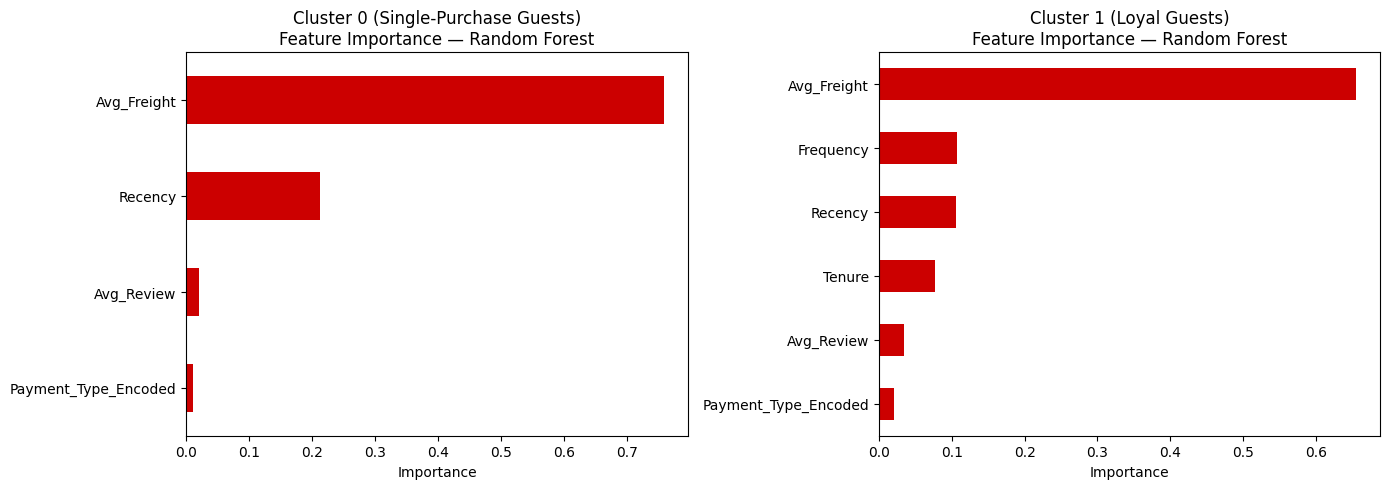

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster 0 feature importance
importances0 = rf_grid0.best_estimator_.feature_importances_
feat_imp0 = pd.Series(importances0, index=cluster0_features).sort_values(ascending=True)
feat_imp0.plot(kind='barh', ax=axes[0], color='#CC0000')
axes[0].set_title('Cluster 0 (Single-Purchase Guests)\nFeature Importance — Random Forest')
axes[0].set_xlabel('Importance')

# Cluster 1 feature importance
importances1 = rf_grid1.best_estimator_.feature_importances_
feat_imp1 = pd.Series(importances1, index=cluster1_features).sort_values(ascending=True)
feat_imp1.plot(kind='barh', ax=axes[1], color='#CC0000')
axes[1].set_title('Cluster 1 (Loyal Guests)\nFeature Importance — Random Forest')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../outputs/fig13_feature_importance_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
final_recommendation = pd.DataFrame({
    'Cluster': ['Cluster 0: Single-Purchase Guests', 'Cluster 1: Loyal Guests'],
    'Guest_Count': [90551, 2806],
    'Recommended_Model': ['Random Forest', 'Random Forest'],
    'Test_R2_80_20': [0.6014, 0.4401],
    'Test_RMSE_80_20': [0.5058, 0.5237],
    'Test_MAE_80_20': [0.3554, 0.4169],
    'Note': [
        'Decision Tree scored marginally higher (R²=0.622) but RF chosen for stability across partitions and lower overfitting risk',
        'Most consistent performer across partitions; small test set (n=141 at 95/5) limits precision, 95% CI: [0.317, 0.578]'
    ]
})

final_recommendation.to_csv('../outputs/final_model_recommendation.csv', index=False)
final_recommendation

,Cluster,Guest_Count,Recommended_Model,Test_R2_80_20,Test_RMSE_80_20,Test_MAE_80_20,Note
0,Cluster 0: Single-Purchase Guests,90551,Random Forest,0.6014,0.5058,0.3554,Decision Tree scored marginally higher (R²=0.6...
1,Cluster 1: Loyal Guests,2806,Random Forest,0.4401,0.5237,0.4169,Most consistent performer across partitions; s...


In [15]:
from sklearn.model_selection import train_test_split

# Step 1: carve out the 10% holdout FIRST before any other splits
# This simulates data the model never saw during training or comparison

X0_trainval, X0_holdout, y0_trainval, y0_holdout = train_test_split(
    X0, y0, test_size=0.10, random_state=99
)

X1_trainval, X1_holdout, y1_trainval, y1_holdout = train_test_split(
    X1, y1, test_size=0.10, random_state=99
)

print(f"Cluster 0 — trainval: {len(X0_trainval)}, holdout: {len(X0_holdout)}")
print(f"Cluster 1 — trainval: {len(X1_trainval)}, holdout: {len(X1_holdout)}")

Cluster 0 — trainval: 81495, holdout: 9056
Cluster 1 — trainval: 2525, holdout: 281


In [16]:
# Step 2: retrain tuned Random Forest on trainval only, then evaluate on holdout once

rf_final_cluster0 = RandomForestRegressor(
    n_estimators=200, max_depth=None, max_features='sqrt', random_state=42
)
rf_final_cluster0.fit(X0_trainval, y0_trainval)
preds0_holdout = rf_final_cluster0.predict(X0_holdout)

rf_final_cluster1 = RandomForestRegressor(
    n_estimators=200, max_depth=10, max_features=0.5, random_state=42
)
rf_final_cluster1.fit(X1_trainval, y1_trainval)
preds1_holdout = rf_final_cluster1.predict(X1_holdout)

holdout_results = {
    'Cluster 0 Holdout': {
        'RMSE': round(np.sqrt(mean_squared_error(y0_holdout, preds0_holdout)), 4),
        'MAE': round(mean_absolute_error(y0_holdout, preds0_holdout), 4),
        'R2': round(r2_score(y0_holdout, preds0_holdout), 4)
    },
    'Cluster 1 Holdout': {
        'RMSE': round(np.sqrt(mean_squared_error(y1_holdout, preds1_holdout)), 4),
        'MAE': round(mean_absolute_error(y1_holdout, preds1_holdout), 4),
        'R2': round(r2_score(y1_holdout, preds1_holdout), 4)
    }
}

for cluster, metrics in holdout_results.items():
    print(f"{cluster}: RMSE={metrics['RMSE']}, MAE={metrics['MAE']}, R²={metrics['R2']}")

Cluster 0 Holdout: RMSE=0.5055, MAE=0.3542, R²=0.601
Cluster 1 Holdout: RMSE=0.5467, MAE=0.4177, R²=0.3132


In [17]:
import pandas as pd
holdout_df = pd.DataFrame(holdout_results).T.reset_index()
holdout_df.columns = ['Cluster', 'RMSE', 'MAE', 'R2']
holdout_df.to_csv('../outputs/holdout_results.csv', index=False)
print("Saved.")

Saved.


In [18]:
# Test 2: Synthetic Stress Test
# Simulate three operating conditions by perturbing the test features

def synthetic_stress_test(model, X_test, y_test, cluster_name):
    results = []
    
    conditions = {
        'Worse': {'Recency': 1.3, 'Avg_Freight': 1.2},      # guests lapsed longer, higher freight
        'Good': {'Recency': 1.0, 'Avg_Freight': 1.0},        # baseline, no change
        'Excellent': {'Recency': 0.7, 'Avg_Freight': 0.85}   # more recent guests, lower freight
    }
    
    for condition, multipliers in conditions.items():
        X_perturbed = X_test.copy()
        for feature, multiplier in multipliers.items():
            if feature in X_perturbed.columns:
                X_perturbed[feature] = X_perturbed[feature] * multiplier
        
        preds = model.predict(X_perturbed)
        results.append({
            'Cluster': cluster_name,
            'Condition': condition,
            'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 4),
            'MAE': round(mean_absolute_error(y_test, preds), 4),
            'R2': round(r2_score(y_test, preds), 4)
        })
    
    return pd.DataFrame(results)

stress_cluster0 = synthetic_stress_test(rf_final_cluster0, X0_holdout, y0_holdout, 'Cluster 0')
stress_cluster1 = synthetic_stress_test(rf_final_cluster1, X1_holdout, y1_holdout, 'Cluster 1')

stress_results = pd.concat([stress_cluster0, stress_cluster1], ignore_index=True)
print(stress_results.to_string(index=False))

stress_results.to_csv('../outputs/stress_test_results.csv', index=False)
print("\nSaved.")

  Cluster Condition   RMSE    MAE      R2
Cluster 0     Worse 0.8144 0.6659 -0.0359
Cluster 0      Good 0.5055 0.3542  0.6010
Cluster 0 Excellent 0.7434 0.5880  0.1368
Cluster 1     Worse 0.5867 0.4556  0.2091
Cluster 1      Good 0.5467 0.4177  0.3132
Cluster 1 Excellent 0.5649 0.4330  0.2669

Saved.


In [19]:
print("Test 1 and Test 2 complete. Files saved:")
print("- outputs/holdout_results.csv")
print("- outputs/stress_test_results.csv")

Test 1 and Test 2 complete. Files saved:
- outputs/holdout_results.csv
- outputs/stress_test_results.csv
